# 1. Inspeção dos Dados (versão explicada passo a passo)

> Este notebook é uma cópia **funcional** de `notebooks/01_data_inspection.ipynb`, com o mesmo código e os mesmos resultados, mas com explicações detalhadas de cada linha: o que é cada biblioteca, o que cada função faz, por que ela está sendo chamada e como ler o resultado. A ideia é que qualquer pessoa do grupo consiga acompanhar, mesmo sem nunca ter usado Python para dados.

Base utilizada: **Breast Cancer Wisconsin (Diagnostic)**, com exames classificados como tumor maligno (`M`) ou benigno (`B`).

**Proveniência.** O conjunto foi criado por W. N. Street, W. H. Wolberg e O. L. Mangasarian (Universidade de Wisconsin, 1993) a partir de imagens digitalizadas de punção aspirativa por agulha fina (PAAF) de massas mamárias. Na PAAF, uma agulha fina retira uma pequena amostra de células do nódulo; essa amostra é fotografada no microscópio e, a partir da imagem, um programa mede características dos núcleos das células (tamanho, formato, textura etc.). Essas medidas são as colunas da nossa base.

A fonte primária é o UCI Machine Learning Repository, distribuído sob licença CC BY 4.0; a cópia usada neste projeto é a redistribuição do Kaggle, salva em `data/raw/breast_cancer_wisconsin.csv`.

- UCI: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Kaggle: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**O que esta etapa faz.** Antes de treinar qualquer modelo de machine learning, precisamos conhecer os dados: quantas linhas e colunas existem, que tipo de informação cada coluna guarda, se há valores faltando, linhas repetidas, valores absurdos etc. Isso se chama **inspeção** (ou "olhar os dados"). Aqui **nada é modificado**: apenas observamos e anotamos os problemas. As correções ficam para a etapa de limpeza (`02_data_cleaning.ipynb`).

## 0. Antes de começar: o que é tudo isso?

### O que é um notebook Jupyter?
Um notebook é um arquivo `.ipynb` composto de **células**. Existem dois tipos:

- **Célula de texto (Markdown)**: como esta aqui. Serve para explicar, documentar, escrever títulos.
- **Célula de código**: contém código Python. Quando você a executa, o resultado aparece logo abaixo dela.

Para executar uma célula, clique nela e pressione **Shift + Enter**. As células de código devem ser executadas **em ordem, de cima para baixo**, porque cada uma pode depender de variáveis criadas nas anteriores (por exemplo, a variável `df` criada na seção 1.2 é usada em todas as seguintes).

Uma regra importante do notebook: **a última linha de uma célula de código, se for uma expressão (não uma atribuição), é exibida automaticamente** abaixo da célula. É por isso que várias células terminam com algo como `df.head()` sem `print`: o notebook mostra o resultado sozinho.

### O que é Python?
Python é a linguagem de programação usada aqui. É a mais popular em ciência de dados porque tem uma sintaxe simples e um ecossistema enorme de bibliotecas prontas.

### O que é uma biblioteca?
Uma biblioteca é um conjunto de funções prontas que alguém já escreveu e que nós reaproveitamos. Em vez de programar do zero como ler um arquivo ou calcular uma média, usamos a função da biblioteca. Neste notebook usamos três:

| Biblioteca | Apelido usual | Para que serve |
|---|---|---|
| **pandas** | `pd` | Manipular tabelas (ler CSV, filtrar linhas, calcular estatísticas por coluna). É o "Excel programável" do Python. |
| **NumPy** | `np` | Operações matemáticas e numéricas eficientes (aqui usamos só a constante `np.pi`). O pandas é construído em cima do NumPy. |
| **Matplotlib** | `plt` | Desenhar gráficos. |

### O que é um DataFrame?
É a estrutura principal do pandas: uma **tabela** com linhas e colunas, parecida com uma planilha. Cada coluna tem um nome e um tipo (número inteiro, número decimal, texto...). Cada linha tem um **índice**, que por padrão é um número começando em `0`.

Uma única coluna de um DataFrame (ou uma única linha) é chamada de **Series**. Muitas funções do pandas devolvem uma Series, e a maneira de ler o resultado é "nome da coluna à esquerda, valor à direita".

### O que é um CSV?
CSV significa *Comma-Separated Values* (valores separados por vírgula). É um arquivo de texto simples em que cada linha é um registro e as colunas são separadas por vírgulas. A primeira linha normalmente é o **cabeçalho**, com os nomes das colunas. É o formato mais comum para distribuir dados tabulares.

### Notação usada nas explicações
- `objeto.funcao()` significa "chame a função `funcao` que pertence a `objeto`". Por exemplo, `df.head()` chama a função `head` do DataFrame `df`.
- Encadear várias funções com pontos (`df.isnull().sum()`) significa aplicar uma depois da outra: primeiro `isnull()`, depois `sum()` no resultado.

## 1.1 Importação das bibliotecas

**O que vamos fazer:** carregar as bibliotecas na memória para poder usá-las no restante do notebook.

**Linha por linha:**

- `import numpy as np`: carrega a biblioteca NumPy e dá a ela o apelido `np`. Depois disso, tudo do NumPy é acessado como `np.alguma_coisa`. O apelido é só uma convenção para escrever menos; praticamente todo código Python de dados usa `np`, `pd` e `plt`.
- `import pandas as pd`: mesma ideia, para o pandas.
- `import matplotlib.pyplot as plt`: carrega apenas o submódulo `pyplot` do Matplotlib, que é a parte usada para desenhar gráficos.
- `pd.set_option("display.max_columns", 12)`: ajusta uma configuração do pandas. Nossa tabela tem 33 colunas; se o pandas tentasse mostrar todas, a saída ficaria ilegível. Com esse limite, ele mostra as primeiras e as últimas colunas e coloca `...` no meio. Isso afeta **só a exibição**, não os dados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 12)

Essa célula não exibe nada: importar bibliotecas não produz saída. Se ela rodar sem mensagem de erro, deu certo. Se aparecer `ModuleNotFoundError`, a biblioteca não está instalada no ambiente (veja o README do projeto, seção de setup).

## 1.2 Carregamento da base

**O que vamos fazer:** ler o arquivo CSV do disco e transformá-lo em um DataFrame chamado `df`.

**Linha por linha:**

- `DATA_PATH = "../data/raw/breast_cancer_wisconsin.csv"`: cria uma **variável** (uma "caixinha" com nome) chamada `DATA_PATH` que guarda um texto com o caminho do arquivo. Escrever o nome em MAIÚSCULAS é uma convenção para dizer "isso é uma constante, não muda durante o notebook".
  - O caminho é **relativo** à pasta onde este notebook está. `..` significa "a pasta de cima". Este notebook está em `group-infos/`, então `../data/raw/...` sobe para a raiz do projeto e entra em `data/raw/`.
- `df = pd.read_csv(DATA_PATH)`: chama a função `read_csv` do pandas, que abre o arquivo, entende o cabeçalho, separa as colunas pelas vírgulas, tenta adivinhar o tipo de cada coluna (número ou texto) e devolve um DataFrame. Guardamos esse DataFrame na variável `df` (abreviação de *DataFrame*, nome padrão na comunidade).

A partir daqui, `df` é a nossa tabela e tudo no notebook gira em torno dela.

In [2]:
DATA_PATH = "../data/raw/breast_cancer_wisconsin.csv"

df = pd.read_csv(DATA_PATH)

Também não há saída aqui, porque a última linha é uma **atribuição** (`df = ...`), e o notebook só exibe expressões. Se aparecer `FileNotFoundError`, o caminho está errado ou o CSV não está em `data/raw/`.

## 1.3 Visualização inicial dos dados

**O que vamos fazer:** dar uma primeira olhada na tabela para conferir se o arquivo foi lido corretamente.

### `df.head()`
`head` significa "cabeça". A função devolve as **primeiras 5 linhas** do DataFrame (5 é o padrão; `df.head(10)` mostraria 10). É a forma mais rápida de responder: "o arquivo foi lido do jeito certo? As colunas têm os nomes esperados? Os valores fazem sentido?"

Como é a última expressão da célula, o notebook exibe a tabela automaticamente.

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,...,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,...,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,...,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,...,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,...,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Como ler o resultado:**

- A coluna mais à esquerda, sem nome, em negrito (`0, 1, 2, 3, 4`) é o **índice**: o número da linha. Python conta a partir de zero.
- `id` é o identificador do exame; `diagnosis` é o diagnóstico (`M` = maligno, `B` = benigno). Essa é a coluna que queremos prever no futuro, chamada de **variável alvo** (*target*).
- As colunas seguintes (`radius_mean`, `texture_mean`, ...) são as medidas dos núcleos celulares.
- O `...` no meio é o efeito do `display.max_columns = 12` que configuramos: existem colunas escondidas ali.
- A última coluna, `Unnamed: 32`, está cheia de `NaN`. **NaN** (*Not a Number*) é como o pandas representa um valor **ausente/vazio**. Já é um primeiro sinal de problema, que vamos confirmar mais adiante.
- A linha final, `5 rows x 33 columns`, resume o tamanho do que foi exibido.

### `df.tail()`
`tail` significa "cauda". Devolve as **últimas 5 linhas**. Por que olhar o fim do arquivo? Porque é comum que CSVs tenham linhas de lixo no final (totais, linhas em branco, comentários) que bagunçam a leitura. Olhar o fim confirma que os dados terminam limpos.

In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,...,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,...,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,...,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,...,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,...,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


**Como ler o resultado:** os índices agora vão de `564` a `568`. Como o índice começa em 0, isso indica 569 linhas no total (0 até 568). As últimas linhas têm o mesmo formato das primeiras, ou seja, o arquivo termina normalmente, sem lixo. `Unnamed: 32` continua vazia.

### O que significam as colunas?

Cada linha da tabela é **um exame de uma paciente**. Além de `id` e `diagnosis`, as colunas descrevem os núcleos das células observados nas imagens da PAAF. Existem **10 características** medidas:

| Característica | Significado simples |
|---|---|
| `radius` (raio) | Tamanho do núcleo, como o raio de um círculo |
| `texture` (textura) | Variação nos tons de cinza da imagem; textura "áspera" ou "lisa" |
| `perimeter` (perímetro) | Comprimento do contorno do núcleo |
| `area` (área) | Área ocupada pelo núcleo |
| `smoothness` (suavidade) | Quão regular é o contorno (variação local do raio) |
| `compactness` (compacidade) | perímetro² / área; mede o quanto o formato é "compacto" |
| `concavity` (concavidade) | Intensidade das "reentrâncias" no contorno |
| `concave points` (pontos côncavos) | Quantidade de reentrâncias no contorno |
| `symmetry` (simetria) | Quão simétrico é o núcleo |
| `fractal_dimension` (dimensão fractal) | Medida de irregularidade do contorno ("costa litorânea": quanto mais recortada, maior) |

Como cada imagem tem **vários núcleos**, cada característica foi resumida de **três formas**, gerando 10 × 3 = 30 colunas numéricas:

- `_mean`: a **média** dos valores de todos os núcleos da imagem.
- `_se`: o **erro padrão** (*standard error*). Em termos simples, é uma medida de quanto os valores dos núcleos variam entre si dentro da mesma imagem. Se todos os núcleos têm quase o mesmo raio, o `radius_se` é pequeno; se variam muito, é grande.
- `_worst`: a **média dos três maiores valores** encontrados na imagem. O nome ("pior") vem do fato de que núcleos maiores e mais irregulares tendem a indicar malignidade.

Exemplo: `radius_mean` é o raio médio dos núcleos; `radius_worst` é a média dos três maiores raios.

## 1.4 Dimensões do dataset

**O que vamos fazer:** descobrir exatamente quantas linhas e quantas colunas a tabela tem, e listar os nomes de todas as colunas (inclusive as que ficaram escondidas no `...`).

**Linha por linha:**

- `df.shape`: devolve o "formato" da tabela como um par de números `(linhas, colunas)`. Esse par é uma **tupla** em Python.
- `n_rows, n_cols = df.shape`: "desempacota" a tupla em duas variáveis de uma vez. É o mesmo que escrever `n_rows = df.shape[0]` e `n_cols = df.shape[1]`, só que mais curto.
- `print(f"Linhas: {n_rows}")`: `print` exibe um texto na tela. O `f` antes das aspas cria uma **f-string**: tudo entre chaves `{}` é substituído pelo valor da variável. Então `{n_rows}` vira `569`.

In [5]:
n_rows, n_cols = df.shape
print(f"Linhas: {n_rows}")
print(f"Colunas: {n_cols}")

Linhas: 569
Colunas: 33


Agora a lista completa dos nomes das colunas:

- `df.columns`: devolve os nomes das colunas em um objeto próprio do pandas (chamado `Index`).
- `.tolist()`: converte esse objeto em uma **lista** comum do Python, que o notebook exibe de forma mais legível (um nome por linha).

In [6]:
df.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

**Como ler o resultado:** a base possui **569 registros** (exames) e **33 colunas**: `id`, `diagnosis`, as 30 medidas (10 características × 3 formas) e a coluna suspeita `Unnamed: 32`. Repare também que três colunas têm **espaço no nome** (`concave points_mean`, `concave points_se`, `concave points_worst`), enquanto todas as outras usam `_`. Vamos voltar a isso.

## 1.5 Informações gerais e tipos das variáveis

**O que vamos fazer:** verificar o **tipo de dado** de cada coluna e quantos valores preenchidos ela tem. Isso importa porque, por exemplo, uma coluna de números que foi lida como texto (por causa de uma vírgula ou um caractere estranho) não pode ser usada em cálculos.

### `df.info()`
Imprime um resumo técnico da tabela. Diferente das outras funções, `info()` já imprime sozinha (não precisa de `print`).

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

**Como ler o resultado, linha por linha:**

- `<class 'pandas.DataFrame'>`: confirma que `df` é um DataFrame.
- `RangeIndex: 569 entries, 0 to 568`: o índice vai de 0 a 568, ou seja, 569 linhas.
- `Data columns (total 33 columns)`: 33 colunas.
- Em seguida, uma tabela com uma linha por coluna:
  - `#`: posição da coluna (começando em 0).
  - `Column`: nome da coluna.
  - `Non-Null Count`: quantos valores **não vazios** a coluna tem. `569 non-null` significa que está completa. `0 non-null` (caso da `Unnamed: 32`) significa que está totalmente vazia.
  - `Dtype`: o **tipo de dado**:
    - `int64`: número inteiro (ex.: `842302`).
    - `float64`: número decimal, "com ponto flutuante" (ex.: `17.99`). O `64` é a quantidade de bits usada para guardar o número; não precisa se preocupar com isso.
    - `str` (ou `object` em versões mais antigas do pandas): texto.
- No fim, `memory usage`: quanto de memória RAM a tabela ocupa.

### `df.dtypes.value_counts()`
Uma forma resumida de ver os tipos:

- `df.dtypes`: devolve uma Series com o tipo de cada coluna.
- `.value_counts()`: **conta quantas vezes cada valor aparece**. É uma das funções mais usadas do pandas: dada uma lista de valores, responde "quantos de cada?". Aqui, responde "quantas colunas de cada tipo?".

In [8]:
df.dtypes.value_counts()

float64    31
int64       1
str         1
Name: count, dtype: int64

**Como ler o resultado:** 31 colunas `float64` (as 30 medidas + `Unnamed: 32`, que o pandas leu como decimal porque só tem NaN), 1 coluna `int64` (`id`) e 1 coluna de texto (`diagnosis`).

### Procurando nomes de coluna problemáticos
A célula abaixo usa uma **list comprehension**, uma forma compacta de criar uma lista em Python. Lida em português, `[col for col in df.columns if condicao]` significa: "monte uma lista com cada `col` de `df.columns`, mas só as que satisfazem a `condicao`".

A condição é `" " in col or col.startswith("Unnamed")`:
- `" " in col`: verdadeiro se o nome contém um espaço.
- `col.startswith("Unnamed")`: verdadeiro se o nome começa com "Unnamed" (é assim que o pandas batiza colunas que não tinham nome no cabeçalho).
- `or`: basta uma das duas ser verdadeira.

Por que nos importamos com espaços nos nomes? Porque colunas com espaço não podem ser acessadas com a sintaxe curta `df.nome_da_coluna` e podem causar problemas em algumas bibliotecas de modelagem. Não é um erro grave, mas é bom saber.

In [9]:
[col for col in df.columns if " " in col or col.startswith("Unnamed")]

['concave points_mean',
 'concave points_se',
 'concave points_worst',
 'Unnamed: 32']

**Conclusão da seção:** as 30 variáveis de medida foram lidas como `float64` (número decimal), como esperado, e `diagnosis` é a única coluna textual. Há uma coluna não prevista, `Unnamed: 32`, gerada por uma **vírgula sobrando no final do cabeçalho** do CSV (o pandas viu uma coluna a mais sem nome e sem valores). As colunas `concave points_*` contêm espaço no nome.

## 1.6 Estatísticas descritivas

**O que vamos fazer:** calcular números-resumo (média, mínimo, máximo etc.) de cada coluna para entender a "cara" dos dados: a escala de cada variável, se existem valores estranhos, se a distribuição é simétrica ou não.

### `df.drop(columns=["id"]).describe().T`

- `df.drop(columns=["id"])`: devolve **uma cópia** da tabela **sem** a coluna `id`. Não faz sentido calcular a média de um identificador, então tiramos ela do cálculo. Importante: `drop` **não altera** `df`; ele devolve uma nova tabela. `df` continua intacto.
- `.describe()`: calcula, para cada coluna numérica, oito estatísticas:
  - `count`: quantidade de valores não vazios.
  - `mean`: **média** (soma de tudo dividido pela quantidade).
  - `std`: **desvio padrão**, uma medida de "espalhamento". Se `std` é pequeno, os valores ficam todos perto da média; se é grande, estão espalhados.
  - `min`: menor valor.
  - `25%`: **primeiro quartil**. Se você ordenar os valores do menor para o maior, 25% deles ficam abaixo desse número.
  - `50%`: **mediana**. Metade dos valores está abaixo, metade acima. É o "valor do meio".
  - `75%`: **terceiro quartil**. 75% dos valores ficam abaixo.
  - `max`: maior valor.
- `.T`: **transpõe** a tabela (troca linhas por colunas). Sem o `.T`, teríamos 8 linhas e 31 colunas, ilegível na tela. Com o `.T`, ficam 31 linhas (uma por variável) e 8 colunas (uma por estatística).

In [10]:
df.drop(columns=["id"]).describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Como ler o resultado:** cada linha é uma variável. Olhe, por exemplo, `radius_mean`: média 14,1, mínimo 7,0, máximo 28,1. Compare com `area_mean`: média 655, máximo 2.501. E com `smoothness_mean`: média 0,096, máximo 0,16. As escalas são **completamente diferentes**, e isso vai ter consequências (explicadas logo abaixo).

### Criando a tabela `features` (só as medidas)
Nas próximas células vamos repetir várias análises apenas sobre as **30 colunas de medida**. Para não ter que escrever `df.drop(...)` toda hora, criamos uma tabela auxiliar chamada `features` (termo usado em machine learning para as variáveis de entrada do modelo).

- `df.select_dtypes("number")`: seleciona só as colunas numéricas (descarta `diagnosis`, que é texto).
- `.drop(columns=["id"])`: tira o `id`.
- `.dropna(axis=1, how="all")`: remove colunas que estejam **inteiramente vazias** (`how="all"` = "todos os valores são NaN"). Isso elimina a `Unnamed: 32`. O `axis=1` significa "olhe para colunas"; `axis=0` seria "olhe para linhas". Essa convenção (0 = linhas, 1 = colunas) aparece em várias funções do pandas.

Resultado: `features` tem 569 linhas e exatamente as 30 medidas.

### Amplitude de cada variável
Depois, montamos uma tabela nova, `value_range`, para enxergar a **escala** de cada variável:

- `pd.DataFrame({...})`: cria um DataFrame a partir de um **dicionário**, em que cada chave vira o nome de uma coluna e cada valor vira o conteúdo dela.
- `features.min()`: devolve uma Series com o menor valor de cada coluna. `features.max()`: o maior.
- `value_range["amplitude"] = value_range["max"] - value_range["min"]`: cria uma coluna nova subtraindo as outras duas, valor a valor. **Amplitude** é a diferença entre o maior e o menor valor.
- `.sort_values("amplitude", ascending=False)`: ordena a tabela pela coluna `amplitude`, do maior para o menor (`ascending=False` = "não crescente").

In [11]:
features = df.select_dtypes("number").drop(columns=["id"]).dropna(axis=1, how="all")

value_range = pd.DataFrame({"min": features.min(), "max": features.max()})
value_range["amplitude"] = value_range["max"] - value_range["min"]
value_range.sort_values("amplitude", ascending=False)

,min,max,amplitude
area_worst,185.200000,4254.00000,4068.800000
area_mean,143.500000,2501.00000,2357.500000
area_se,6.802000,542.20000,535.398000
perimeter_worst,50.410000,251.20000,200.790000
perimeter_mean,43.790000,188.50000,144.710000
texture_worst,12.020000,49.54000,37.520000
texture_mean,9.710000,39.28000,29.570000
radius_worst,7.930000,36.04000,28.110000
perimeter_se,0.757000,21.98000,21.223000
radius_mean,6.981000,28.11000,21.129000


**Como ler o resultado:** no topo estão as variáveis de **área**, com amplitude na casa dos milhares (`area_worst` vai de 185 a 4.254). No fim da lista, variáveis como `smoothness_se` e `fractal_dimension_se` variam menos de 0,1. Ou seja, há variáveis milhares de vezes "maiores" que outras.

**Por que isso importa?** Muitos modelos de machine learning calculam **distâncias** entre exames ou somam contribuições das variáveis. Exemplos:
- **KNN** (*k-nearest neighbors*, "k vizinhos mais próximos"): classifica um exame olhando os exames mais parecidos com ele. "Parecido" é medido por distância numérica. Se uma variável vai até 4.254 e outra até 0,2, a distância será dominada pela primeira, e a segunda será praticamente ignorada, mesmo que seja mais importante clinicamente.
- **Regressão logística**: aprende um "peso" para cada variável. Escalas muito diferentes atrapalham o algoritmo de aprendizado e a interpretação dos pesos.

A solução é a **padronização** (deixar todas as variáveis na mesma escala, por exemplo com média 0 e desvio padrão 1). Isso será feito no pré-processamento, não aqui.

### Contando zeros
Zeros merecem atenção porque às vezes representam "valor faltante disfarçado" (alguém preencheu 0 por não ter o dado). A célula abaixo conta quantos zeros há em cada coluna:

- `features == 0`: compara **cada célula** da tabela com zero e devolve uma tabela do mesmo tamanho, só com `True` e `False`.
- `.sum()`: soma cada coluna. Em Python, `True` vale 1 e `False` vale 0, então somar uma coluna de `True/False` é o mesmo que **contar quantos `True`**. Resultado: uma Series com a quantidade de zeros por coluna.
- `.loc[lambda s: s > 0]`: filtra a Series, mantendo só as colunas em que a contagem é maior que zero. `lambda s: s > 0` é uma **função anônima** (uma função de uma linha, sem nome) que recebe a Series `s` e devolve `True` onde `s > 0`. É só uma forma compacta de escrever o filtro.

In [12]:
(features == 0).sum().loc[lambda s: s > 0]

concavity_mean          13
concave points_mean     13
concavity_se            13
concave points_se       13
concavity_worst         13
concave points_worst    13
dtype: int64

**Como ler o resultado:** só seis colunas têm zeros, todas de **concavidade** e **pontos côncavos**, e todas com exatamente 13 zeros. Faz sentido: se o núcleo é perfeitamente "liso", sem nenhuma reentrância, a concavidade é zero, e os pontos côncavos também. E se a média é zero, o erro padrão e o "pior" também são. Ou seja, são os **mesmos 13 exames** em todas as seis colunas. Esses zeros são **valores reais**, não dados faltantes, e devem ser mantidos.

### Assimetria: a distribuição é "torta"?
Agora vamos comparar **média** com **mediana** e calcular a **assimetria** (*skewness*) de cada variável.

Intuição: imagine os salários de uma empresa. A maioria ganha entre 3 e 5 mil, e o dono ganha 500 mil. A **média** é puxada para cima pelo dono; a **mediana** (o salário do "funcionário do meio") não. Quando a média fica bem acima da mediana, dizemos que a distribuição tem **cauda à direita** (alguns valores muito altos) e é **assimétrica positiva**.

- `features.mean()`: média por coluna. `features.median()`: mediana por coluna.
- `features.skew()`: **coeficiente de assimetria** por coluna. Regra de bolso: perto de 0 = simétrica; acima de 1 = bastante assimétrica à direita; abaixo de -1 = bastante assimétrica à esquerda.
- `shape["media/mediana"] = (...).round(2)`: razão média ÷ mediana, arredondada para 2 casas. Se for perto de 1, média e mediana coincidem (simetria); quanto maior que 1, mais a cauda à direita puxa a média.
- `.sort_values("assimetria", ascending=False).round(3)`: ordena da mais assimétrica para a menos, e arredonda tudo para 3 casas decimais para facilitar a leitura.

In [13]:
shape = pd.DataFrame({
    "media": features.mean(),
    "mediana": features.median(),
    "assimetria": features.skew(),
})
shape["media/mediana"] = (shape["media"] / shape["mediana"]).round(2)
shape.sort_values("assimetria", ascending=False).round(3)

,media,mediana,assimetria,media/mediana
area_se,40.337,24.530,5.447,1.64
concavity_se,0.032,0.026,5.110,1.23
fractal_dimension_se,0.004,0.003,3.924,1.19
perimeter_se,2.866,2.287,3.444,1.25
radius_se,0.405,0.324,3.089,1.25
smoothness_se,0.007,0.006,2.314,1.10
symmetry_se,0.021,0.019,2.195,1.10
compactness_se,0.025,0.020,1.902,1.25
area_worst,880.583,686.500,1.859,1.28
fractal_dimension_worst,0.084,0.080,1.663,1.05


**Como ler o resultado:** `area_se` está no topo, com assimetria 5,4 e média 40 contra mediana 24,5 (razão 1,64): a maioria dos exames tem `area_se` baixo, mas alguns têm valores enormes que puxam a média. As variáveis `_se` dominam o topo da lista, o que é esperado, porque medidas de variação costumam ter esse comportamento. Lá no fim ficam variáveis próximas de 0, como as de suavidade, que são aproximadamente simétricas.

### Outliers: valores extremos
**Outlier** é um valor muito distante dos demais. O critério mais usado para detectá-los é o do **intervalo interquartil (IQR)**:

1. Calcule o primeiro quartil (Q1, 25%) e o terceiro quartil (Q3, 75%) de cada coluna.
2. IQR = Q3 − Q1 (é a "faixa central" onde vivem os 50% de valores do meio).
3. Qualquer valor **abaixo de Q1 − 1,5 × IQR** ou **acima de Q3 + 1,5 × IQR** é considerado outlier. O 1,5 é uma convenção clássica da estatística.

**Linha por linha:**

- `q1, q3 = features.quantile(0.25), features.quantile(0.75)`: calcula os dois quartis de cada coluna de uma vez (duas atribuições na mesma linha).
- `iqr = q3 - q1`.
- `is_outlier = (features < q1 - 1.5 * iqr) | (features > q3 + 1.5 * iqr)`: uma tabela de `True/False` do tamanho de `features`, com `True` onde o valor é extremo. O `|` significa **"ou"** aplicado célula a célula (o `or` comum não funciona com tabelas).
- `outliers_by_col = is_outlier.sum().sort_values(ascending=False)`: quantos outliers há em cada coluna, da que tem mais para a que tem menos.
- `rows_with_outlier = is_outlier.any(axis=1)`: para cada **linha** (`axis=1`), `any` responde "há pelo menos um `True` nesta linha?". Resultado: uma Series de `True/False` por exame, dizendo se ele tem algum valor extremo em qualquer coluna.
- `(outliers_by_col > 0).sum()`: quantas colunas têm ao menos um outlier.
- `rows_with_outlier.sum()`: quantos exames têm ao menos um outlier. `rows_with_outlier.mean() * 100`: como `True` = 1 e `False` = 0, a **média de uma coluna de booleanos é a proporção de `True`**; multiplicando por 100, vira porcentagem. O `:.1f` na f-string formata com 1 casa decimal.
- `df.loc[rows_with_outlier, "diagnosis"]`: `loc` seleciona **linhas e colunas por rótulo**. Aqui pega só as linhas em que `rows_with_outlier` é `True` e só a coluna `diagnosis`. Depois `.value_counts()` conta quantos `M` e quantos `B`. `.to_string()` é só para imprimir bonito.
- `outliers_by_col.head(10)`: as 10 colunas com mais outliers.

In [14]:
q1, q3 = features.quantile(0.25), features.quantile(0.75)
iqr = q3 - q1
is_outlier = (features < q1 - 1.5 * iqr) | (features > q3 + 1.5 * iqr)

outliers_by_col = is_outlier.sum().sort_values(ascending=False)
rows_with_outlier = is_outlier.any(axis=1)

print(f"Colunas com ao menos um outlier (IQR): {(outliers_by_col > 0).sum()} de {len(outliers_by_col)}")
print(f"Exames com ao menos um outlier: {rows_with_outlier.sum()} ({rows_with_outlier.mean() * 100:.1f}%)")
print("Por classe:")
print(df.loc[rows_with_outlier, "diagnosis"].value_counts().to_string())
outliers_by_col.head(10)

Colunas com ao menos um outlier (IQR): 29 de 30
Exames com ao menos um outlier: 171 (30.1%)
Por classe:
diagnosis
M    114
B     57


area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
dtype: int64

**Como ler o resultado:** 29 das 30 colunas têm ao menos um outlier, e 171 exames (30,1% da base) têm ao menos um valor extremo em alguma coluna. O dado mais importante é a divisão por classe: **114 malignos contra 57 benignos**. Como só 37% da base é maligna, os outliers estão **concentrados nos tumores malignos**. Isso indica que eles não são erros de medição: são exatamente os casos mais graves, com núcleos maiores e mais irregulares. **Não devemos removê-los**, senão jogaríamos fora os exemplos que o modelo mais precisa aprender.

### Consistência física
Por fim, verificamos se existem valores **impossíveis**:

- `(features < 0).sum().sum()`: o primeiro `.sum()` conta negativos por coluna; o segundo soma tudo em um único número. Medidas de tamanho, área etc. nunca podem ser negativas.
- `features.columns[features.min() == 0]`: lista as colunas cujo valor mínimo é exatamente zero (deve bater com as seis colunas de concavidade vistas antes).
- Depois, um teste de **coerência geométrica**. Se o núcleo fosse um círculo perfeito de raio *r*, teríamos área = π r² e perímetro = 2 π r. Então:
  - `area_mean / (np.pi * radius_mean ** 2)` deveria ficar perto de 1. O `**` é o operador de potência em Python (`x ** 2` = x ao quadrado) e `np.pi` é a constante π (3,14159...).
  - `perimeter_mean / (2 * np.pi * radius_mean)` também deveria ficar perto de 1.
  - Se alguma razão fosse, por exemplo, 5 ou 0,1, seria sinal de erro na coluna (unidade errada, valores trocados).
- `geometry.describe().T.round(3)`: as mesmas estatísticas-resumo da seção anterior, agora para essas duas razões.

In [15]:
print(f"Valores negativos: {(features < 0).sum().sum()}")
print(f"Colunas com mínimo igual a zero: {features.columns[features.min() == 0].tolist()}")

geometry = pd.DataFrame({
    "area / (pi * raio^2)": df["area_mean"] / (np.pi * df["radius_mean"] ** 2),
    "perimetro / (2 * pi * raio)": df["perimeter_mean"] / (2 * np.pi * df["radius_mean"]),
})
geometry.describe().T.round(3)

Valores negativos: 0
Colunas com mínimo igual a zero: ['concavity_mean', 'concave points_mean', 'concavity_se', 'concave points_se', 'concavity_worst', 'concave points_worst']


,count,mean,std,min,25%,50%,75%,max
area / (pi * raio^2),569.0,0.981,0.015,0.917,0.972,0.981,0.988,1.064
perimetro / (2 * pi * raio),569.0,1.033,0.021,0.983,1.017,1.030,1.044,1.133


**Como ler o resultado:** nenhum valor negativo. Os zeros são só nas seis colunas de concavidade, como já sabíamos. As razões geométricas ficam entre 0,92 e 1,06 (área) e entre 0,98 e 1,13 (perímetro), ou seja, sempre perto de 1: os núcleos são aproximadamente circulares e as três colunas (raio, área, perímetro) são coerentes entre si. O perímetro fica um pouco acima de 1 porque contornos irregulares são mais longos que o de um círculo perfeito, o que também faz sentido.

### Resumo da seção 1.6

**Assimetria.** Das 30 variáveis, 22 têm assimetria acima de 1 e 7 acima de 2, todas com cauda à direita. O caso mais forte é `area_se` (assimetria 5,4; média de 40 contra mediana de 24,5), seguido de `concavity_se` e `fractal_dimension_se`. As variáveis `_se` concentram as maiores distorções, o que é esperado para medidas de dispersão. Apenas as medidas de suavidade e `concave points_worst` ficam próximas da simetria.

**Outliers.** Pelo critério do intervalo interquartil, 29 das 30 variáveis têm valores extremos e 171 exames (30,1%) apresentam ao menos um. Desses, 114 são malignos e 57 benignos: os extremos estão concentrados na classe de interesse, o que indica que são casos clinicamente relevantes e não erros de medição. A recomendação para a limpeza é **não remover** esses registros; a etapa de pré-processamento deve considerar transformação logarítmica nas variáveis mais assimétricas ou um escalonador robusto a outliers (os dois termos estão explicados no glossário ao final).

**Consistência física.** Não há valores negativos. Os únicos zeros ocorrem nas seis colunas de concavidade. As razões geométricas entre área, perímetro e raio ficam próximas de 1 em todos os exames, como se espera de núcleos aproximadamente circulares. Não foram encontrados valores fisicamente impossíveis ou inconsistentes entre colunas relacionadas.

## 1.7 Verificação de valores ausentes

**O que vamos fazer:** contar, coluna por coluna, quantos valores estão vazios (NaN). Valores ausentes são um dos problemas mais comuns em dados reais e a maioria dos modelos **não aceita** NaN como entrada, então precisamos saber onde eles estão para decidir o que fazer (preencher, remover a linha, remover a coluna).

**Linha por linha:**

- `df.isnull()`: devolve uma tabela de `True/False` do mesmo tamanho de `df`, com `True` onde o valor é NaN.
- `.sum()`: conta os `True` por coluna, ou seja, **quantos ausentes cada coluna tem**.
- `df.isnull().mean() * 100`: a média de booleanos é a proporção de `True`; vezes 100, vira **percentual de ausentes** por coluna. `.round(2)` arredonda para 2 casas.
- Montamos um DataFrame `missing` com essas duas colunas (`ausentes` e `percentual`).
- `missing[missing["ausentes"] > 0]`: **filtro**. Dentro dos colchetes, `missing["ausentes"] > 0` gera uma Series de `True/False`; usar isso como índice mantém só as linhas `True`. Assim, exibimos apenas as colunas que **têm** algum ausente, em vez de 33 linhas cheias de zero.

In [16]:
missing = pd.DataFrame({
    "ausentes": df.isnull().sum(),
    "percentual": (df.isnull().mean() * 100).round(2),
})
missing[missing["ausentes"] > 0]

,ausentes,percentual
Unnamed: 32,569,100.0


Agora o total geral, com e sem a coluna problemática:

- `df.isnull().sum().sum()`: o primeiro `sum` conta por coluna; o segundo soma todas as colunas em um único número.
- `df.drop(columns=['Unnamed: 32'], errors='ignore')`: mesma conta, mas sem a `Unnamed: 32`. O `errors='ignore'` diz ao pandas: "se essa coluna não existir, não dê erro, só siga em frente". É uma proteção para o caso de o CSV ser corrigido no futuro.

In [17]:
print(f"Total de valores ausentes: {df.isnull().sum().sum()}")
print(f"Total sem a coluna 'Unnamed: 32': {df.drop(columns=['Unnamed: 32'], errors='ignore').isnull().sum().sum()}")

Total de valores ausentes: 569
Total sem a coluna 'Unnamed: 32': 0


**Como ler o resultado:** a única coluna com valores ausentes é `Unnamed: 32`, vazia em **todos os 569 registros** (100%). Sem ela, o total de ausentes é **zero**: as demais colunas estão completas. Isso é ótimo, porque não precisaremos preencher nada; basta remover a coluna fantasma na limpeza.

## 1.8 Verificação de registros duplicados

**O que vamos fazer:** conferir se algum exame aparece mais de uma vez. Linhas duplicadas distorcem estatísticas e, pior, podem fazer o mesmo exame cair tanto no conjunto de treino quanto no de teste do modelo, inflando artificialmente a avaliação.

**Linha por linha:**

- `df.duplicated()`: devolve uma Series de `True/False`, uma por linha, marcando `True` nas linhas que são **cópias exatas de uma linha anterior** (a primeira ocorrência fica `False`; só as repetições ficam `True`). `.sum()` conta quantas repetições existem.
- `df['id'].duplicated().sum()`: mesma verificação, mas só na coluna `id`. Responde: "algum identificador aparece mais de uma vez?". Isso pegaria o caso de um mesmo exame ter sido cadastrado duas vezes com valores levemente diferentes.
- `df.drop(columns=['id']).duplicated().sum()`: o oposto: ignora o `id` e compara só as medidas. Responde: "existem dois exames com medidas idênticas mas ids diferentes?". Isso pegaria o caso de um exame duplicado ter recebido um novo id por engano.

Fazemos as três verificações porque cada uma pega um tipo diferente de duplicata.

In [18]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"IDs duplicados: {df['id'].duplicated().sum()}")
print(f"Linhas duplicadas desconsiderando o id: {df.drop(columns=['id']).duplicated().sum()}")

Linhas duplicadas: 0
IDs duplicados: 0
Linhas duplicadas desconsiderando o id: 0


**Como ler o resultado:** zero em todas as três. Não há registros duplicados, nem considerando o `id` nem desconsiderando-o, e cada `id` aparece uma única vez.

## 1.9 Distribuição inicial da variável diagnosis

**O que vamos fazer:** olhar a **variável alvo**, aquela que o modelo vai tentar prever. Precisamos saber quantos exames são benignos e quantos são malignos, porque a proporção entre as classes influencia como treinar e como avaliar o modelo.

**Linha por linha:**

- `df["diagnosis"]`: seleciona a coluna `diagnosis` (uma Series).
- `.value_counts()`: conta quantas vezes cada valor aparece (quantos `B`, quantos `M`).
- `.value_counts(normalize=True)`: em vez de contagem, devolve a **proporção** (entre 0 e 1). Multiplicamos por 100 para virar porcentagem e arredondamos.
- Montamos um DataFrame com as duas colunas lado a lado.

In [19]:
diagnosis_counts = pd.DataFrame({
    "quantidade": df["diagnosis"].value_counts(),
    "percentual": (df["diagnosis"].value_counts(normalize=True) * 100).round(2),
})
diagnosis_counts

,quantidade,percentual
diagnosis,,
B,357,62.74
M,212,37.26


### O gráfico de barras
A mesma informação, agora visual. Um **gráfico de barras** é o ideal para comparar quantidades entre categorias: cada categoria vira uma barra, e a altura da barra é a quantidade.

**Linha por linha:**

- `df["diagnosis"].value_counts()`: a contagem, como antes.
- `.rename({"B": "Benigno (B)", "M": "Maligno (M)"})`: troca os rótulos `B` e `M` por nomes mais descritivos, só para o gráfico ficar legível.
- `.plot(kind="bar", ...)`: o pandas tem um atalho para desenhar gráficos com o Matplotlib. `kind="bar"` = gráfico de barras verticais. Os outros argumentos:
  - `color=["steelblue", "salmon"]`: a cor de cada barra (azul para benigno, salmão para maligno).
  - `edgecolor="black"`: contorno preto nas barras.
  - `figsize=(6, 4)`: tamanho da figura em polegadas (largura, altura).
- `ax = ...`: a função devolve o objeto **eixos** (*axes*), que representa a área do gráfico. Guardamos em `ax` para poder personalizar.
- `ax.set_title(...)`: título do gráfico.
- `ax.set_xlabel(...)` / `ax.set_ylabel(...)`: rótulos dos eixos horizontal (x) e vertical (y).
- `ax.tick_params(axis="x", rotation=0)`: por padrão o pandas gira os rótulos do eixo x em 90°; aqui forçamos 0° para ficarem na horizontal.
- `ax.bar_label(ax.containers[0])`: escreve o valor numérico em cima de cada barra. `ax.containers[0]` é o conjunto de barras desenhado.
- `plt.tight_layout()`: ajusta as margens para nada ficar cortado.
- `plt.show()`: exibe a figura.

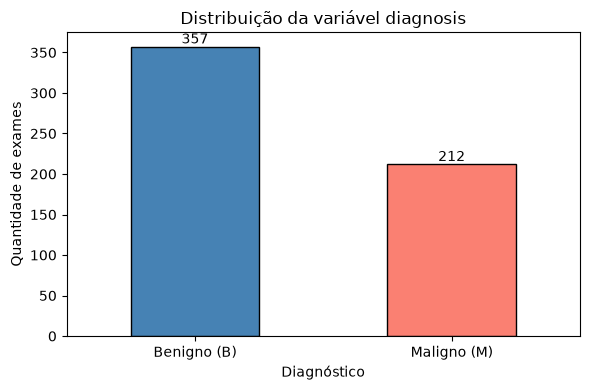

In [20]:
ax = df["diagnosis"].value_counts().rename({"B": "Benigno (B)", "M": "Maligno (M)"}).plot(
    kind="bar", color=["steelblue", "salmon"], edgecolor="black", figsize=(6, 4)
)
ax.set_title("Distribuição da variável diagnosis")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Quantidade de exames")
ax.tick_params(axis="x", rotation=0)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

**O que o gráfico representa:** duas barras, uma por classe. A barra azul (benigno) é mais alta, com 357 exames; a barra salmão (maligno) tem 212. Visualmente já dá para ver que a base tem mais casos benignos, mas a diferença não é gigantesca.

**Como interpretar:** a base tem 357 casos benignos (62,7%) e 212 malignos (37,3%). Quando as classes têm quantidades diferentes, dizemos que a base é **desbalanceada**. Aqui o desbalanceamento é **moderado** (não é 99% contra 1%, por exemplo) e não impede a modelagem, mas traz duas recomendações:

1. **Separação estratificada.** Quando dividirmos os dados em treino, validação e teste, devemos garantir que cada parte mantenha a mesma proporção 63/37. Sem isso, por azar, o conjunto de teste poderia ficar com pouquíssimos casos malignos e a avaliação seria pouco confiável.
2. **Atenção ao recall da classe maligna.** Neste problema, o erro mais grave é o **falso negativo**: dizer que um tumor maligno é benigno (a paciente deixaria de ser tratada). O **recall** (também chamado de sensibilidade) mede justamente "de todos os casos malignos reais, quantos o modelo acertou?". Um modelo com 90% de acurácia geral mas que erra metade dos malignos seria inaceitável, então a acurácia sozinha não basta.

### Comparando as médias por classe
Última análise: para cada medida `_mean`, qual é a média entre os benignos e qual é a média entre os malignos? Isso dá uma pista de quais variáveis mais **diferenciam** as duas classes.

**Linha por linha:**

- `mean_cols = [col for col in df.columns if col.endswith("_mean")]`: list comprehension que monta a lista das 10 colunas cujo nome termina em `_mean`.
- `df.groupby("diagnosis")`: **agrupa** as linhas pelo valor de `diagnosis`, formando dois grupos: todos os `B` e todos os `M`. É a operação "separar em grupos e calcular algo para cada grupo", equivalente a uma tabela dinâmica do Excel.
- `[mean_cols]`: dentro de cada grupo, olhe só essas 10 colunas.
- `.mean()`: calcule a média de cada coluna em cada grupo. Resultado: 2 linhas (B e M) × 10 colunas.
- `.T`: transpõe, para ficar 10 linhas (variáveis) × 2 colunas (B e M), mais fácil de ler.
- `by_class["razao M/B"] = (by_class["M"] / by_class["B"]).round(2)`: nova coluna com a razão maligno ÷ benigno. Se a razão é 1, a variável tem a mesma média nas duas classes (não ajuda a diferenciar). Se é 3, os malignos têm em média o triplo (ajuda muito).
- `.sort_values("razao M/B", ascending=False).round(4)`: ordena da maior razão para a menor.

In [21]:
mean_cols = [col for col in df.columns if col.endswith("_mean")]

by_class = df.groupby("diagnosis")[mean_cols].mean().T
by_class["razao M/B"] = (by_class["M"] / by_class["B"]).round(2)
by_class.sort_values("razao M/B", ascending=False).round(4)

diagnosis,B,M,razao M/B
concavity_mean,0.0461,0.1608,3.49
concave points_mean,0.0257,0.0880,3.42
area_mean,462.7902,978.3764,2.11
compactness_mean,0.0801,0.1452,1.81
perimeter_mean,78.0754,115.3654,1.48
radius_mean,12.1465,17.4628,1.44
texture_mean,17.9148,21.6049,1.21
smoothness_mean,0.0925,0.1029,1.11
symmetry_mean,0.1742,0.1929,1.11
fractal_dimension_mean,0.0629,0.0627,1.00


**Como ler o resultado:** concavidade e pontos côncavos são, em média, **3,4 a 3,5 vezes maiores** nos tumores malignos, e a área é o **dobro**. Já textura, suavidade e simetria diferem pouco entre as classes, e a dimensão fractal praticamente não muda (razão 1,00). Isso significa que concavidade, pontos côncavos e área são as candidatas mais fortes a "variáveis que separam benigno de maligno".

Essa leitura é apenas indicativa: comparar médias não conta a história toda (duas classes podem ter a mesma média e distribuições muito diferentes). Isso será aprofundado na análise exploratória, com distribuições por classe e matriz de correlação.

## 1.10 Conclusões da inspeção

A base contém 569 exames e 33 colunas: `id`, `diagnosis`, 30 variáveis numéricas de medida e uma coluna vazia (`Unnamed: 32`). Não há valores ausentes nas variáveis de medida, registros duplicados, valores negativos ou inconsistências geométricas entre colunas relacionadas. A variável alvo está distribuída em 357 casos benignos (62,7%) e 212 malignos (37,3%).

**Tratamentos indicados para a limpeza**

| Item | Situação encontrada | Tratamento | Por quê |
|---|---|---|---|
| `Unnamed: 32` | 100% vazia, gerada pela vírgula ao final do cabeçalho | Remover | Não tem informação nenhuma e os modelos não aceitam NaN |
| `id` | Identificador único, sem valor preditivo | Remover | Um número de cadastro não diz nada sobre o tumor; se ficasse, o modelo poderia "decorar" ids |
| `diagnosis` | Categórica (`M`/`B`), sem variantes de grafia | Converter para `1`/`0` | Modelos trabalham com números; `1` = maligno (classe de interesse), `0` = benigno |
| Valores ausentes | Nenhum nas variáveis de medida | Nenhum | |
| Duplicatas | Nenhuma | Nenhum | |
| Valores inconsistentes | Nenhum negativo ou fisicamente impossível | Nenhum | |
| Zeros em concavidade | 13 exames, valores plausíveis | Manter | São núcleos sem reentrâncias, um valor real |
| Outliers (IQR) | 171 exames (30,1%), 2/3 deles malignos | Manter; tratar na escala, não por exclusão | São os casos mais graves, exatamente os que o modelo precisa aprender |
| `concave points_*` | Espaço no nome da coluna | Renomear (opcional) | Facilita o acesso às colunas no código |

**Implicações para as etapas seguintes**

- As diferenças de escala entre as variáveis exigem **padronização** no pipeline de pré-processamento (colocar todas na mesma escala, para que nenhuma domine as outras só por ter números maiores).
- A forte assimetria à direita, sobretudo nas variáveis `_se`, sugere avaliar **transformação logarítmica** ou **escalonador robusto** antes de modelos sensíveis à escala.
- Os outliers concentram-se na classe maligna e não devem ser removidos, sob risco de descartar justamente os casos que o modelo precisa aprender.
- O desbalanceamento moderado entre as classes indica **separação estratificada** e avaliação por **recall** e **F1-score**, além da acurácia.
- Concavidade, pontos côncavos e área são as candidatas mais fortes a variáveis discriminantes e merecem destaque na análise exploratória.

## Glossário

| Termo | Significado |
|---|---|
| **Acurácia** | Percentual de acertos do modelo, contando todas as classes juntas. Pode enganar em bases desbalanceadas. |
| **Assimetria (skewness)** | Medida de quão "torta" é uma distribuição. Positiva = cauda à direita (alguns valores muito altos). |
| **Booleano** | Valor que só pode ser `True` (verdadeiro) ou `False` (falso). Em somas, vale 1 e 0. |
| **DataFrame** | Tabela do pandas, com linhas e colunas. |
| **Desvio padrão (std)** | Medida de espalhamento dos valores ao redor da média. |
| **Escalonador robusto (RobustScaler)** | Forma de padronizar usando mediana e IQR em vez de média e desvio padrão, de modo que outliers não distorçam a escala. |
| **F1-score** | Média harmônica entre precisão e recall; resume os dois em um número só. Útil quando as classes são desbalanceadas. |
| **Falso negativo** | O modelo diz "benigno" mas o tumor é maligno. O erro mais grave neste problema. |
| **Feature** | Variável de entrada do modelo (aqui, as 30 medidas). |
| **f-string** | Texto em Python com `f` antes das aspas, em que `{variavel}` é substituído pelo valor. |
| **IQR** | Intervalo interquartil: Q3 − Q1, a faixa onde ficam os 50% centrais dos valores. |
| **KNN** | Modelo que classifica um exame olhando os *k* exames mais parecidos com ele. Sensível à escala das variáveis. |
| **List comprehension** | Forma compacta de criar uma lista: `[x for x in lista if condicao]`. |
| **Média** | Soma de todos os valores dividida pela quantidade. |
| **Mediana** | Valor do meio quando os dados estão ordenados. Não é afetada por valores extremos. |
| **NaN** | *Not a Number*: valor ausente/vazio. |
| **Outlier** | Valor muito distante dos demais. |
| **Padronização** | Transformar cada variável para ter média 0 e desvio padrão 1, deixando todas na mesma escala. |
| **Quartil** | Pontos que dividem os dados ordenados em quatro partes iguais (Q1 = 25%, Q2 = mediana, Q3 = 75%). |
| **Recall (sensibilidade)** | De todos os casos realmente positivos (malignos), a fração que o modelo acertou. |
| **Regressão logística** | Modelo de classificação que aprende um peso para cada variável. Sensível à escala. |
| **Separação estratificada** | Dividir treino/validação/teste mantendo a proporção das classes em cada parte. |
| **Series** | Uma única coluna (ou linha) do pandas. |
| **Transformação logarítmica** | Aplicar `log(x)` a uma variável assimétrica para "comprimir" os valores altos e deixar a distribuição mais simétrica. |
| **Variável alvo (target)** | A coluna que o modelo tenta prever; aqui, `diagnosis`. |